In [31]:
import cv2
import numpy as np
from PIL import Image
import tensorflow as tf
from tflite_model_maker import object_detector
import os
import xml.etree.ElementTree as ET
from collections import Counter

In [33]:
# Model loading
model_path = os.path.join("MyModel", "20m", "model.tflite")
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()

In [28]:
def preprocess_image(image_path, input_size):
    """Preprocess the input image to feed to the TFLite model."""
    print(f"Preprocessing image: {image_path}")
    img = tf.io.read_file(image_path)
    img = tf.io.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.uint8)
    original_image = img.numpy()
    original_height, original_width, _ = original_image.shape
    resized_img = tf.image.resize(img, input_size)
    resized_img = resized_img[tf.newaxis, :]
    resized_img = tf.cast(resized_img, dtype=tf.uint8)

    # Debug preprocessing
    print(f"Original Image Shape: {original_image.shape}, Resized Image Shape: {resized_img.shape}")
    return resized_img, original_image, original_width, original_height

In [11]:
def convert_normalized_to_absolute(box, image_width, image_height):
    """Convert a normalized bounding box to absolute coordinates."""
    ymin, xmin, ymax, xmax = box
    return [
        int(ymin * image_height),
        int(xmin * image_width),
        int(ymax * image_height),
        int(xmax * image_width)
    ]

In [ ]:
def detect_objects(interpreter, image, threshold=0.5, original_width=None, original_height=None):
    """Run inference on the image and convert results to absolute coordinates."""
    print("Running inference on the image...")
    try:
        signature_fn = interpreter.get_signature_runner()
        output = signature_fn(images=image)
    except Exception as e:
        print(f"Error during inference: {e}")
        raise

    # Debug model outputs
    count = int(np.squeeze(output['output_0']))
    scores = np.squeeze(output['output_1'])
    classes = np.squeeze(output['output_2'])
    boxes = np.squeeze(output['output_3'])
    print(f"Raw Model Outputs: count={count}, scores={scores}, classes={classes}, boxes={boxes}")

    results = []
    for i in range(count):
        if scores[i] >= threshold:
            abs_box = convert_normalized_to_absolute(
                boxes[i], original_width, original_height
            )
            result = {
                'bounding_box': abs_box,
                'class_id': int(classes[i]),
                'score': scores[i]
            }
            results.append(result)
    print(f"Filtered Results: {results}")
    return results

In [ ]:
def non_maximum_suppression(detections, iou_threshold=0.5):
    print(f"Applying Non-Maximum Suppression on {len(detections)} detections...")
    if len(detections) == 0:
        print("No detections to process for NMS.")
        return []

    boxes = np.array([det['bounding_box'] for det in detections])
    scores = np.array([det['score'] for det in detections])

    # Convert bounding boxes to the format required for NMS (ymin, xmin, ymax, xmax)
    boxes = np.array([[box[0], box[1], box[2], box[3]] for box in boxes])

    # Apply Non-Maximum Suppression
    indices = cv2.dnn.NMSBoxes(boxes.tolist(), scores.tolist(), score_threshold=0.4, nms_threshold=iou_threshold)

    # Debug NMS results
    print(f"NMS kept {len(indices.flatten()) if indices is not None else 0} detections.")
    nms_detections = [detections[i] for i in indices.flatten()] if indices is not None else []

    return nms_detections

In [7]:
def parse_pascal_voc(xml_file):
    print(f"Parsing annotation file: {xml_file}")
    tree = ET.parse(xml_file)
    root = tree.getroot()
    gt_boxes = []
    gt_labels = []

    for obj in root.findall('object'):
        label = obj.find('name').text
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)
        gt_boxes.append([ymin, xmin, ymax, xmax])
        gt_labels.append(label)
    
    print(f"Ground Truth Boxes: {gt_boxes}, Labels: {gt_labels}")
    return gt_boxes, gt_labels

In [6]:
def calculate_iou(box1, box2):
    """Calculate the Intersection over Union (IoU) of two bounding boxes."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area_box1 + area_box2 - intersection
    return intersection / union if union > 0 else 0

In [17]:
def evaluate_detections(detections, ground_truths, iou_threshold):
    """Evaluate detections by matching them to ground truth boxes."""
    tp = 0  # True Positives
    fp = 0  # False Positives
    fn = len(ground_truths)  # False Negatives (start with all GT as unmatched)
    matched_gt = set()
    iou_values = []  # Store IoU values for matched pairs

    for detection in detections:
        det_box = detection['bounding_box']  # [ymin, xmin, ymax, xmax]
        print(f"Detection Box: {det_box}")  # Debugging
        best_iou = 0
        best_gt_idx = -1

        for idx, gt_box in enumerate(ground_truths):
            print(f"Ground Truth Box: {gt_box}")  # Debugging
            if idx in matched_gt:  # Skip already matched GT boxes
                continue

            iou = calculate_iou(det_box, gt_box)
            print(f"Calculated IoU between Detection and GT {idx}: {iou:.2f}")  # Debugging

            if iou > best_iou:
                best_iou = iou
                best_gt_idx = idx

        if best_iou >= iou_threshold:
            tp += 1
            matched_gt.add(best_gt_idx)
            fn -= 1  # Reduce FN count since one GT is matched
            iou_values.append(best_iou)  # Add IoU for this matched pair
        else:
            fp += 1  # Unmatched detection is a false positive

    # Calculate average IoU for this image
    avg_iou = np.mean(iou_values) if iou_values else 0
    print(f"IoU Values for Image: {iou_values}, Avg IoU: {avg_iou:.2f}")  # Debugging

    return tp, fp, fn, iou_values, avg_iou


In [20]:
def process_dataset_with_metrics(dataset_folder, interpreter, detection_threshold, annotation_folder, iou_threshold):
    print(f"Processing dataset: {dataset_folder}")
    image_files = [f for f in os.listdir(dataset_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]
    metrics = Counter()
    results_per_image = []
    all_iou_values = []  # Store IoU values across all images

    for image_file in image_files:
        print(f"\nProcessing image: {image_file}")
        image_path = os.path.join(dataset_folder, image_file)
        xml_file = os.path.join(annotation_folder, os.path.splitext(image_file)[0] + '.xml')

        gt_boxes, gt_labels = parse_pascal_voc(xml_file)

        # Only keep ground truths for class 'mobil'
        gt_boxes = [gt_boxes[i] for i in range(len(gt_boxes)) if gt_labels[i] == 'mobil']

        # Get detections from the model
        preprocessed_image, original_image, original_width, original_height = preprocess_image(
            image_path, input_size=(320, 320)
        )  # Update input size as needed
        detections = detect_objects(
            interpreter, preprocessed_image, threshold=detection_threshold,
            original_width=original_width, original_height=original_height
        )

        # Evaluate detections and get IoU values
        tp, fp, fn, iou_values, avg_iou = evaluate_detections(detections, gt_boxes, iou_threshold=iou_threshold)

        # Accumulate IoU values for overall calculation
        all_iou_values.extend(iou_values)

        print(f"TP: {tp}, FP: {fp}, FN: {fn}, Avg IoU: {avg_iou:.2f}")

        # Update overall metrics
        metrics.update({'TP': tp, 'FP': fp, 'FN': fn})

        # Save per-image results
        results_per_image.append({
            "image_file": image_file,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "IoU": avg_iou,
            "detections": detections,
            "ground_truths": gt_boxes,
        })

    # Calculate overall IoU
    overall_avg_iou = np.mean(all_iou_values) if all_iou_values else 0

    precision = metrics['TP'] / (metrics['TP'] + metrics['FP']) if (metrics['TP'] + metrics['FP']) > 0 else 0
    recall = metrics['TP'] / (metrics['TP'] + metrics['FN']) if (metrics['TP'] + metrics['FN']) > 0 else 0

    print(f"\nOverall Dataset Metrics: Precision={precision:.2f}, Recall={recall:.2f}, Avg IoU={overall_avg_iou:.2f}")
    return {
        "metrics": metrics,
        "results_per_image": results_per_image,
        "precision": precision,
        "recall": recall,
        "overall_avg_iou": overall_avg_iou,
    }


In [44]:
# Paths and thresholds
DATASET_FOLDER = "split/300m/test/images"
ANNOTATION_FOLDER = "split/300m/test/annotations"
DETECTION_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5

# Run and print metrics
results = process_dataset_with_metrics(
    DATASET_FOLDER, interpreter, DETECTION_THRESHOLD, ANNOTATION_FOLDER, iou_threshold=IOU_THRESHOLD
)


Processing dataset: split/300m/test/images

Processing image: 0-cka-147_jpg.rf.d1136a5a3a4b60c7436bc4d3bffe484e.jpg
Parsing annotation file: split/300m/test/annotations\0-cka-147_jpg.rf.d1136a5a3a4b60c7436bc4d3bffe484e.xml
Ground Truth Boxes: [[69, 434, 95, 454]], Labels: ['mobil']
Preprocessing image: split/300m/test/images\0-cka-147_jpg.rf.d1136a5a3a4b60c7436bc4d3bffe484e.jpg
Original Image Shape: (360, 640, 3), Resized Image Shape: (1, 320, 320, 3)
Running inference on the image...
Raw Model Outputs: count=25, scores=[0.10546875 0.0859375  0.08203125 0.046875   0.03515625 0.03515625
 0.03125    0.0234375  0.0234375  0.0234375  0.0234375  0.0234375
 0.0234375  0.01953125 0.01953125 0.01953125 0.01953125 0.01953125
 0.01953125 0.01953125 0.01953125 0.015625   0.015625   0.015625
 0.015625  ], classes=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.], boxes=[[ 6.6306889e-03  8.2144773e-01  3.4336931e-01  9.8779118e-01]
 [ 1.7270017e-01  1.5830097e-01  1.0861

In [45]:
import csv

# Flatten the data and save it as a CSV
csv_file = "Eval_Result/10-25m/300m/20m-300m.csv"
results_per_image = results["results_per_image"]  # Extract from the returned dictionary

with open(csv_file, mode='w', newline='') as f:
    writer = csv.writer(f)
    # Write header
    writer.writerow(["image_file", "TP", "FP", "FN", "IoU", "detections", "ground_truths"])

    # Write the data
    for result in results_per_image:
        writer.writerow([
            result["image_file"],
            result["TP"],
            result["FP"],
            result["FN"],
            f"{result['IoU']:.2f}",  # Format IoU as float with 2 decimals
            str(result["detections"]),  # Convert list to string
            str(result["ground_truths"]),  # Convert list to string
        ])

print(f"Results saved to {csv_file}")


Results saved to Eval_Result/10-25m/300m/20m-300m.csv


In [41]:
print(results_per_image)

[{'image_file': '15M-26-_jpg.rf.9b8289d74145c2e40f87186473d9c364.jpg', 'TP': 2, 'FP': 0, 'FN': 0, 'IoU': 0.8348555371248441, 'detections': [{'bounding_box': [388, 673, 602, 944], 'class_id': 0, 'score': 0.96484375}, {'bounding_box': [730, 688, 1082, 1124], 'class_id': 0, 'score': 0.96484375}], 'ground_truths': [[721, 713, 1080, 1116], [374, 692, 612, 921]]}, {'image_file': '15M-29-_jpg.rf.f7fb25c9b065ae38ec57cb3b50ba15dc.jpg', 'TP': 2, 'FP': 0, 'FN': 0, 'IoU': 0.8526810252882882, 'detections': [{'bounding_box': [531, 770, 730, 1019], 'class_id': 0, 'score': 0.9765625}, {'bounding_box': [798, 993, 1084, 1276], 'class_id': 0, 'score': 0.95703125}], 'ground_truths': [[513, 768, 736, 1000], [796, 1018, 1080, 1280]]}, {'image_file': '15M-41-_jpg.rf.1f0b26a6d5e643f643a7b48843a2fb26.jpg', 'TP': 1, 'FP': 0, 'FN': 0, 'IoU': 0.8112798264642083, 'detections': [{'bounding_box': [869, 1083, 1056, 1276], 'class_id': 0, 'score': 0.97265625}], 'ground_truths': [[850, 1082, 1068, 1265]]}, {'image_file'

R^2

In [107]:
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter

# Function to calculate R-squared
def calculate_r_squared(y_true, y_pred):
    """
    Calculate the R-squared (coefficient of determination) for the model.

    Parameters:
    y_true (numpy array): Ground truth IoU values.
    y_pred (numpy array): Predicted IoU values.
    
    Returns:
    float: R-squared value.
    """
    # Mean of the ground truth values
    y_mean = np.mean(y_true)

    # Sum of squares total (SST)
    sst = np.sum((y_true - y_mean) ** 2)

    # Sum of squares residuals (SSR)
    ssr = np.sum((y_true - y_pred) ** 2)

    # R-squared calculation
    r_squared = 1 - (ssr / sst)

    return r_squared


C:\Users\march\AppData\Local\Temp\ipykernel_6692\2002829442.py:28: RuntimeWarning: divide by zero encountered in double_scalars
  r_squared = 1 - (ssr / sst)


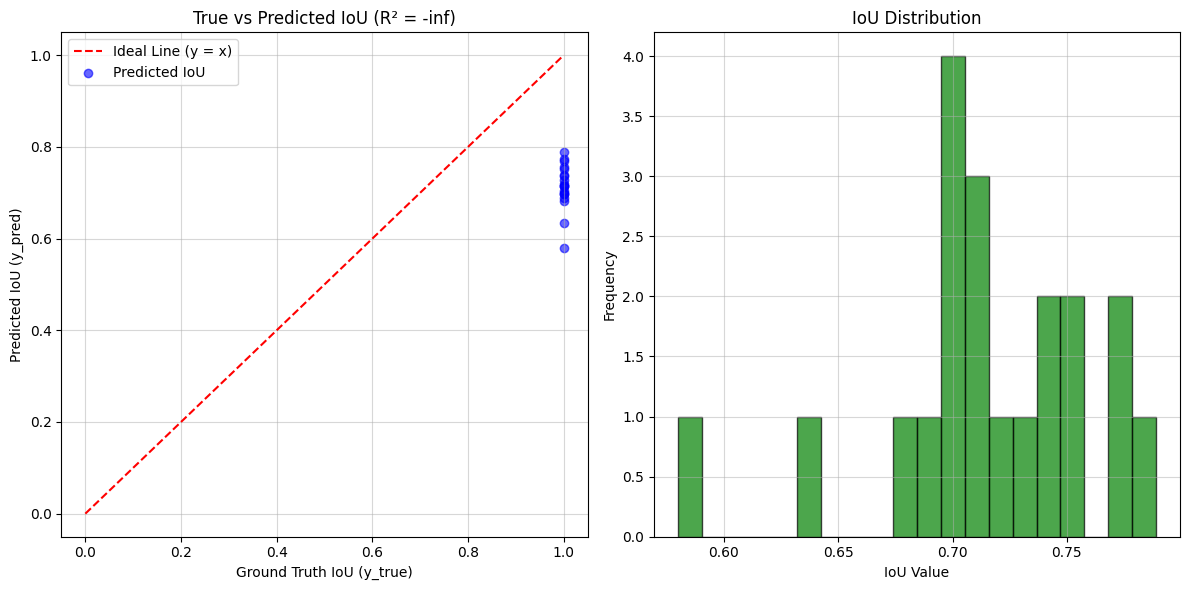

In [ ]:
# Function to plot the R-squared analysis
def plot_r2_analysis(results_per_image):
    """
    Plot R^2 analysis for IoU values and display the R-squared on the plot.

    Parameters:
    results_per_image (list): List of results per image, where each result contains IoU values.
    """
    # Collect IoU values
    y_true = []  # Ground truth IoU values (perfect match = 1)
    y_pred = []  # Predicted IoU values from detections

    for result in results_per_image:
        # Append the ground truth IoU and predicted IoU for each image
        y_true.append(1)  # Perfect IoU for ground truth is 1
        y_pred.append(result["IoU"])  # Use the calculated average IoU for the image

    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calculate R-squared
    r_squared = calculate_r_squared(y_true, y_pred)

    # Scatter plot for true vs predicted
    plt.figure(figsize=(12, 6))
    
    # Scatter plot
    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.6, color='blue', label='Predicted IoU')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Ideal Line (y = x)')
    plt.title(f"True vs Predicted IoU (R² = {r_squared:.4f})")
    plt.xlabel("Ground Truth IoU (y_true)")
    plt.ylabel("Predicted IoU (y_pred)")
    plt.legend()
    plt.grid(alpha=0.5)

    # Histogram for IoU distribution
    plt.subplot(1, 2, 2)
    plt.hist(y_pred, bins=20, alpha=0.7, color='green', edgecolor='black')
    plt.title("IoU Distribution")
    plt.xlabel("IoU Value")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.5)

    # Display the plots
    plt.tight_layout()
    plt.show()


# Use the results to plot the R-squared analysis
plot_r2_analysis(results["results_per_image"])

Predicted IoU values: []
Unique Predicted IoU values: []


: 